# SpaceX S-1 — Space (launch) segment economics

Sibling to the Connectivity notebook. The Space segment is SpaceX's **launch business**: Falcon 9,
Falcon Heavy, and Dragon flown for commercial and government customers — plus the giant, mostly
invisible internal launch operation that deploys Starlink (and, soon, AI compute). On a GAAP basis
the segment *loses money*. This notebook argues that the loss is almost entirely a **Starship
development invoice**, that the underlying customer launch franchise is highly profitable, and then
models what Starship actually unlocks — and roughly when it can start paying for itself.

**Roadmap.**
1. **What the Space segment sells** — Launch Services (point-in-time) vs Launch & Development (over-time, government).
2. **The cadence engine** — a launch monopoly that mostly flies for *itself*; the revenue you don't see.
3. **Unit economics of the customer franchise** — \$/launch, the internal-cost gap.
4. **The GAAP loss is a Starship invoice** — strip R&D and the franchise earns ~\$1.5–1.9B.
5. **Starship: the cost-per-kg lever** — what a 99% cost collapse unlocks, and the accounting hinge.
6. **Modeling Starship revenue** — when it commercializes and what it's worth (bear/base/bull).
7. **Forward FCF** — R&D reversal + modest external lift → cash; squared with ``dcf.py``.

> **Finance terms, plain English.** *Operating income* = revenue minus the costs of running the
> business (incl. R&D), before interest and tax. *Capex* = cash spent on long-lived assets (rockets,
> tooling) that is *capitalized* (put on the balance sheet) and then *depreciated* (expensed a bit
> each year) rather than hitting the P&L all at once. *D&A* = that yearly depreciation charge. The
> Starship story below turns on one rule: today Starship is **expensed** as R&D; at commercialization
> it gets **capitalized** instead — a mechanical swing in reported profit.

In [1]:
# Locate the repo root (the directory containing `analysis/`) so imports work from anywhere.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "analysis")):
    _p = os.path.dirname(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from analysis import data, charts
from analysis.space_economics import (
    SpaceModel, PERIODS, PAYLOAD_T_LEO, COST_PER_KG,
    STARSHIP_RND_SHARE, STARSHIP_RND_SHARE_BAND)
from analysis.connectivity_economics import INTERNAL_LAUNCH_COST_M   # one number, two valuations

charts.apply_style()
NAVY, TEAL, ORANGE = (charts.SEGMENT_COLORS["Space"],
                      charts.SEGMENT_COLORS["Connectivity"],
                      charts.SEGMENT_COLORS["AI"])
GREY = charts.SEGMENT_COLORS["Total Reportable Segments"]

R = SpaceModel().raw()      # per-period Space fundamentals from the S-1 CSVs

def fmt(df, pct=(), one=()):
    """Table display helper: percent for ratio cols, 1 decimal for per-launch cols, else $M integers."""
    spec = {c: ("{:.1%}" if c in pct else ("{:,.1f}" if c in one else "{:,.0f}"))
            for c in df.columns if c in pct or c in one or pd.api.types.is_numeric_dtype(df[c])}
    return df.style.format(spec)

R.T   # the raw S-1 inputs every later calculation is built from

period,FY2023,FY2024,FY2025,Q1-2026
revenue,3557.000000,3796.000000,4086.000000,619.000000
op_income,-1.000000,21.000000,-657.000000,-662.000000
cogs,1669.000000,1541.000000,1352.000000,281.000000
rnd,1538.000000,1835.000000,3004.000000,930.000000
sga,351.000000,375.000000,349.000000,70.000000
impairment,0.000000,24.000000,38.000000,0.000000
da,571.000000,637.000000,757.000000,166.000000
sbc,427.000000,472.000000,515.000000,145.000000
capex,1497.000000,2032.000000,3832.000000,1052.000000
adj_ebitda_reported,997.000000,1154.000000,653.000000,-351.000000


### Charting convention: the FY2026E estimate

We only have one quarter of fiscal 2026 (Q1, to Mar 31). Dropping that three-month stub next to full
years makes every time-series look like the business fell off a cliff, so for the **charts** we replace
it with a full-year estimate, **FY2026E**, built the same way the Connectivity notebook does it: grow
each FY2025 line item by its own **Q1-2026-over-Q1-2025 growth rate**. This is a mechanical run-rate
extrapolation — *if Q1's year-over-year pace holds, where does the full year land?* — not a bottom-up
forecast. FY2026E is drawn **hatched** in every chart to flag it as an estimate; the **tables keep the
actual reported quarter**.

The estimate already carries the §2 signal: customer launches are running *down* (7 vs 12 a year ago,
a ~25-launch full-year pace vs 43 in FY2025) while internal Starlink launches are running *up* (33 vs
24, a ~168 full-year pace vs 122). So on a run-rate basis customer Space revenue softens even as total
cadence and mass-to-orbit keep climbing — exactly the "fly more for ourselves" dynamic, not a decline
in the business.

In [2]:
# FY2026E - annualize the partial Q1-2026 quarter so time-series charts compare like with like.
# Method: grow each FY2025 line item by its own Q1-2026 / Q1-2025 (year-over-year) rate. The tables
# elsewhere keep the ACTUAL reported quarter; only the charts use this estimate.
Q     = SpaceModel().raw(["Q1-2025", "Q1-2026"])     # both first quarters, same columns as R
yoy   = Q.loc["Q1-2026"] / Q.loc["Q1-2025"]          # per-line year-over-year growth
fy26e = R.loc["FY2025"] * yoy
fy26e["impairment"] = 0.0                            # none assumed in the estimate

CHART_PERIODS = ["FY2023", "FY2024", "FY2025", "FY2026E"]
def to_chart(col):
    """Three reported full years from an R column + the FY2026E run-rate estimate."""
    return list(R.loc[["FY2023", "FY2024", "FY2025"], col]) + [fy26e[col]]

# Reused legend handle flagging the hatched estimate bar/marker in every chart below.
EST_PATCH = Patch(facecolor="0.9", edgecolor="#888", hatch="//", label="FY2026E (Q1-2026 run-rate est.)")

show = ["revenue", "launch_services", "launch_dev", "customer_launches", "starlink_launches", "mass_to_orbit"]
est = pd.DataFrame({"FY2025 (actual)": R.loc["FY2025", show],
                    "Q1 YoY growth":   yoy[show] - 1,
                    "FY2026E (est.)":  fy26e[show]})
fmt(est, pct=["Q1 YoY growth"])

,FY2025 (actual),Q1 YoY growth,FY2026E (est.)
revenue,"4,086",-28.4%,"2,924"
launch_services,"2,576",-41.7%,"1,502"
launch_dev,"1,510",-3.3%,"1,459"
customer_launches,43,-41.7%,25
starlink_launches,122,37.5%,168
mass_to_orbit,"2,213",23.6%,"2,734"


## 1. What the Space segment sells

Two revenue buckets, split by *how* the S-1 recognizes them (MD&A p.98):

- **Launch Services** — recognized *at a point in time*, when the customer's payload reaches orbit.
  This is the classic Falcon 9 / Falcon Heavy / Dragon mission sold to a commercial or government
  customer. Lumpy, per-launch, ~\$60M a flight.
- **Launch & Development** — recognized *over time* (cost-to-cost), tied to **long-term government
  contracts** (development programs, crew/cargo). Smoother, contract-driven. The S-1 explicitly
  expects this to grow as a *share* of Space revenue as the government backlog is worked off.

One caveat dominates everything that follows, and it's the same accounting fact the Connectivity
notebook leans on: **Space revenue reflects only *customer* activity.** Launches dedicated to
Starlink earn *no* inter-segment revenue here — their cost is capitalized into Connectivity instead.
So the Space P&L is the tip of the iceberg; most of the cadence is flown internally, for free.

,Launch Services,Launch & Development,Total Space revenue,Launch Services %
period,,,,
FY2023,"1,964","1,593","3,557",55.2%
FY2024,"2,584","1,212","3,796",68.1%
FY2025,"2,576","1,510","4,086",63.0%
Q1-2026,330,289,619,53.3%


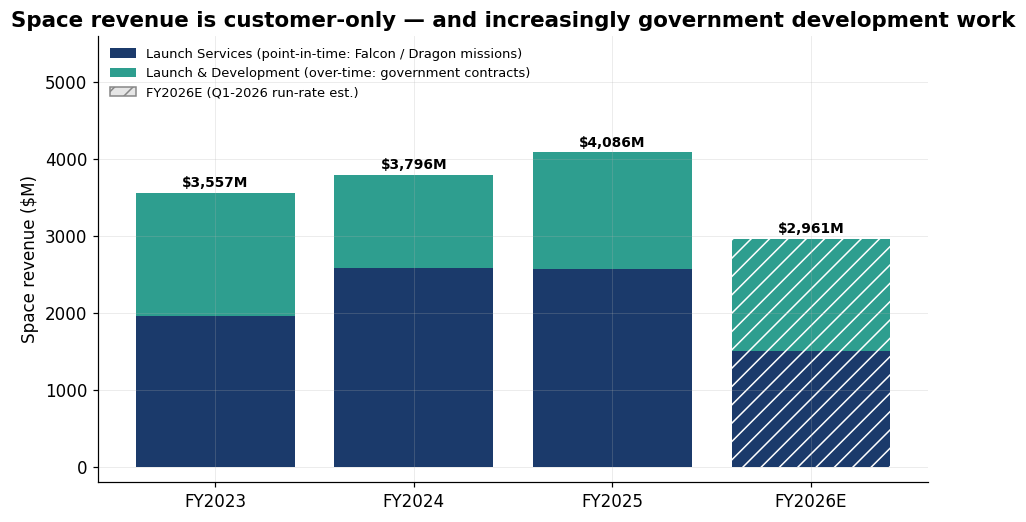

In [3]:
# Revenue recognition mix: Launch Services (point-in-time) vs Launch & Development (over-time).
split = pd.DataFrame({
    "Launch Services":      R.launch_services,
    "Launch & Development": R.launch_dev,
})
split["Total Space revenue"] = split.sum(axis=1)
split["Launch Services %"]   = R.ls_pct
display(fmt(split, pct=["Launch Services %"]))      # table keeps the actual reported Q1-2026

fig, ax = plt.subplots(figsize=(8.6, 4.9))
x = np.arange(len(CHART_PERIODS))
ls, ld = to_chart("launch_services"), to_chart("launch_dev")
b_ls = ax.bar(x, ls, color=NAVY, label="Launch Services (point-in-time: Falcon / Dragon missions)")
b_ld = ax.bar(x, ld, bottom=ls, color=TEAL, label="Launch & Development (over-time: government contracts)")
for b in (b_ls, b_ld):                              # flag the FY2026E (last) bar as an estimate
    b[-1].set_hatch("//"); b[-1].set_edgecolor("white"); b[-1].set_linewidth(0)
for i in range(len(CHART_PERIODS)):
    ax.text(i, ls[i] + ld[i] + 80, f"${ls[i]+ld[i]:,.0f}M", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_ylabel("Space revenue ($M)")
ax.set_ylim(0, 5000)                                # headroom so the legend clears the bars and labels
ax.set_title("Space revenue is customer-only — and increasingly government development work")
ax.legend(handles=[b_ls, b_ld, EST_PATCH], loc="upper left", fontsize=8.5)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "space_revenue_split", layout=False); plt.show()

Customer Space revenue is nearly flat — **\$3.8B → \$4.1B** across FY2024–FY2025, and *down*
year-over-year in Q1-2026. For a company growing total revenue ~33%, that looks like stagnation. It
isn't: it's a deliberate choice to point the rocket inward (§2). Note too that **Launch &
Development** — the government contract book — is a third to a half of the segment and rising, exactly
as the S-1 guides. The customer launch business is real, but it is *not* where SpaceX's launch value
mostly shows up.

## 2. The cadence engine — a launch monopoly that mostly flies for itself

SpaceX put **>80% of the world's mass to orbit** in 2025 (S-1, p.80). Yet customer launches barely
moved — **33 → 45 → 43** Falcon flights for customers across FY2023–25 — while *internal* Starlink
launches went **63 → 89 → 122**. The binding constraint on Space revenue is **not** customer demand
or launch capacity; it's that SpaceX keeps absorbing its own capacity to deploy Starlink. The S-1 is
blunt: *"When an expected customer payload for a planned launch is not available, we instead use
launch capacity for our satellites,"* and *"we expect Space revenue growth to continue to be lower
than total company revenue growth as our internal business continues to absorb most of the growth in
our launch capacity."*

So the right way to see Space is as a **launch monopoly whose output is mostly consumed internally**.
The chart below splits the cadence; the table then values the *invisible* internal launches two ways —
at the price a customer would pay, and at SpaceX's internal cost — to size the revenue that never
appears on the Space P&L.

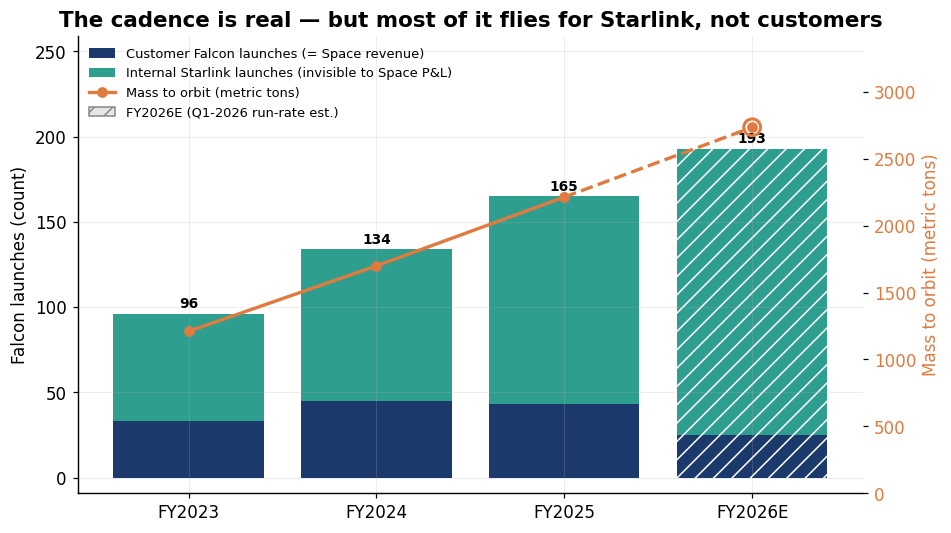

In [4]:
# Falcon cadence: customer vs internal Starlink launches, with mass-to-orbit overlaid (FY2026E = est.).
fig, ax = plt.subplots(figsize=(8.8, 5))
x = np.arange(len(CHART_PERIODS))
cust, intl = to_chart("customer_launches"), to_chart("starlink_launches")
b_c = ax.bar(x, cust, color=NAVY, label="Customer Falcon launches (= Space revenue)")
b_i = ax.bar(x, intl, bottom=cust, color=TEAL, label="Internal Starlink launches (invisible to Space P&L)")
for b in (b_c, b_i):
    b[-1].set_hatch("//"); b[-1].set_edgecolor("white"); b[-1].set_linewidth(0)
tot = [c + i for c, i in zip(cust, intl)]
for i in range(len(CHART_PERIODS)):
    ax.text(i, tot[i] + 3.5, f"{tot[i]:.0f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CHART_PERIODS)
ax.set_ylabel("Falcon launches (count)")
ax.set_ylim(0, max(tot) * 1.20)
ax.set_title("The cadence is real — but most of it flies for Starlink, not customers")

mass = to_chart("mass_to_orbit")
ax2 = ax.twinx()
ax2.plot(x[:3], mass[:3], color=ORANGE, marker="o", lw=2.2)
ax2.plot(x[2:], mass[2:], color=ORANGE, marker="o", lw=2.2, ls="--")          # dashed into the estimate
ax2.scatter([x[-1]], [mass[-1]], s=120, facecolors="none", edgecolors=ORANGE, lw=2, zorder=5)
ax2.set_ylabel("Mass to orbit (metric tons)", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE); ax2.grid(False)
ax2.set_ylim(0, max(mass) * 1.25)

ax.legend(handles=[b_c, b_i,
                   plt.Line2D([], [], color=ORANGE, marker="o", lw=2.2, label="Mass to orbit (metric tons)"),
                   EST_PATCH],
          loc="upper left", fontsize=8.5)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "space_cadence", layout=False); plt.show()

In [5]:
# Value the invisible internal launches: at market price vs at internal cost ($17.5M, from Connectivity sec.6).
market_price = R.launch_services / R.customer_launches      # S-1-implied $/customer launch (blended Falcon/Dragon)

inv = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
inv["Customer launches"]            = R.customer_launches
inv["Internal launches"]            = R.starlink_launches
inv["Market $/launch"]              = market_price
inv["Reported Space revenue"]       = R.revenue
inv["Internal @ market (shadow)"]   = R.starlink_launches * market_price
inv["Internal @ cost ($17.5M)"]     = R.starlink_launches * INTERNAL_LAUNCH_COST_M
inv["Vertical-integration value"]   = inv["Internal @ market (shadow)"] - inv["Internal @ cost ($17.5M)"]
inv["True launch output @ market"]  = inv["Reported Space revenue"] + inv["Internal @ market (shadow)"]
display(fmt(inv, one=["Market $/launch"]))

shadow25 = inv.loc["FY2025", "Internal @ market (shadow)"]
true25   = inv.loc["FY2025", "True launch output @ market"]
print(f"FY2025: reported Space revenue ${R.revenue['FY2025']:,.0f}M captures only "
      f"{R.revenue['FY2025']/true25:.0%} of the ~${true25:,.0f}M of launch SpaceX actually flew at market value.")
print(f"        ${shadow25:,.0f}M of launch was consumed internally to deploy Starlink "
      f"(it lands in Connectivity's capitalized cost base at ${INTERNAL_LAUNCH_COST_M}M/launch, not as revenue).")

,Customer launches,Internal launches,Market $/launch,Reported Space revenue,Internal @ market (shadow),Internal @ cost ($17.5M),Vertical-integration value,True launch output @ market
period,,,,,,,,
FY2023,33,63,59.5,"3,557","3,749","1,102","2,647","7,306"
FY2024,45,89,57.4,"3,796","5,111","1,558","3,553","8,907"
FY2025,43,122,59.9,"4,086","7,309","2,135","5,174","11,395"
Q1-2026,7,33,47.1,619,"1,556",578,978,"2,175"


FY2025: reported Space revenue $4,086M captures only 36% of the ~$11,395M of launch SpaceX actually flew at market value.
        $7,309M of launch was consumed internally to deploy Starlink (it lands in Connectivity's capitalized cost base at $17.5M/launch, not as revenue).


The reported **\$4.1B** of FY2025 Space revenue is less than **40%** of the ~\$11B of launch SpaceX
actually flew if internal Starlink missions were priced at market. The other ~\$7B is *consumed
internally* — it shows up not as Space revenue but as a low (\$17.5M/launch) capitalized cost inside
Connectivity, which is precisely the launch-cost moat the Connectivity notebook quantified. **Space
is a monopoly that mostly subsidizes its own sister segment.** Judging it on its standalone P&L
misses the point of the vertical integration.

## 3. Unit economics of the customer launch franchise

Take the customer business on its own terms. Each customer Falcon mission sells for **~\$60M**
(Launch Services revenue ÷ customer launches — a blend of Falcon 9, Falcon Heavy, and Dragon), and
SpaceX's *internal* marginal cost of a reused Falcon 9 is **~\$17.5M** (triangulated in the
Connectivity notebook, §6: external estimates and the S-1's own Satellites PP&E line both land on the
\$15–20M band). That spread is the franchise. The point of this section isn't a precise margin — it's
that the **customer-facing launch business throws off cash**, which makes the segment's reported loss
(next section) all the more obviously a *choice*.

In [6]:
# Customer-franchise economics: revenue per launch vs internal cost, and the implied contribution.
fran = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
fran["Customer launches"]        = R.customer_launches
fran["Launch Services rev"]      = R.launch_services
fran["Market $/launch"]          = market_price
fran["Internal $/launch"]        = INTERNAL_LAUNCH_COST_M
fran["Spread $/launch"]          = market_price - INTERNAL_LAUNCH_COST_M
fran["Implied launch margin %"]  = 1 - INTERNAL_LAUNCH_COST_M / market_price
display(fmt(fran, pct=["Implied launch margin %"], one=["Market $/launch", "Internal $/launch", "Spread $/launch"]))

print("Each customer flight sells for ~3-4x its internal cost. The customer launch franchise is")
print("structurally profitable; the segment-level loss below is created entirely downstream, by R&D.")

,Customer launches,Launch Services rev,Market $/launch,Internal $/launch,Spread $/launch,Implied launch margin %
period,,,,,,
FY2023,33,"1,964",59.5,17.5,42.0,70.6%
FY2024,45,"2,584",57.4,17.5,39.9,69.5%
FY2025,43,"2,576",59.9,17.5,42.4,70.8%
Q1-2026,7,330,47.1,17.5,29.6,62.9%


Each customer flight sells for ~3-4x its internal cost. The customer launch franchise is
structurally profitable; the segment-level loss below is created entirely downstream, by R&D.


A ~\$60M price on a ~\$17.5M internal cost is a **~70% gross spread** per flight (the reported
segment cost of revenue is higher because it carries second stages, launch operations, overhead, and
depreciation — but the marginal economics are unambiguous). The customer franchise is a cash machine.
Now watch it disappear into a loss.

## 4. The GAAP loss is a Starship invoice

Here is the central claim of the whole notebook. Walk the FY2025 Space P&L from the top:

| | \$M |
|---|---:|
| Revenue | 4,086 |
| − Cost of revenue | (1,352) |
| − SG&A | (349) |
| − Impairment | (38) |
| **= Core operating income (pre-R&D)** | **2,347** |
| − Research & development | (3,004) |
| **= Reported operating income** | **(657)** |

The launch-and-services operation earns **\$2,347M before R&D — a 57% margin.** The segment only
shows a loss because it then spends **\$3,004M on R&D**, and the S-1 tells us exactly what that is:
*"in 2025 we accelerated our timeline for Starship development, increasing R&D in our Space segment
to \$3,004 million, compared to \$1,835 million in 2024"* (the entire **\$1,169M** increase is
Starship), and *"A majority of Starship costs are currently expensed to Research and development as
incurred."*

So the right mental model isn't "money-losing launch segment." It's "**profitable launch franchise
writing a multi-billion-dollar check to build Starship.**" The bridge chart makes the size of that
check obvious; the sensitivity then asks what the franchise earns once Starship R&D normalizes.

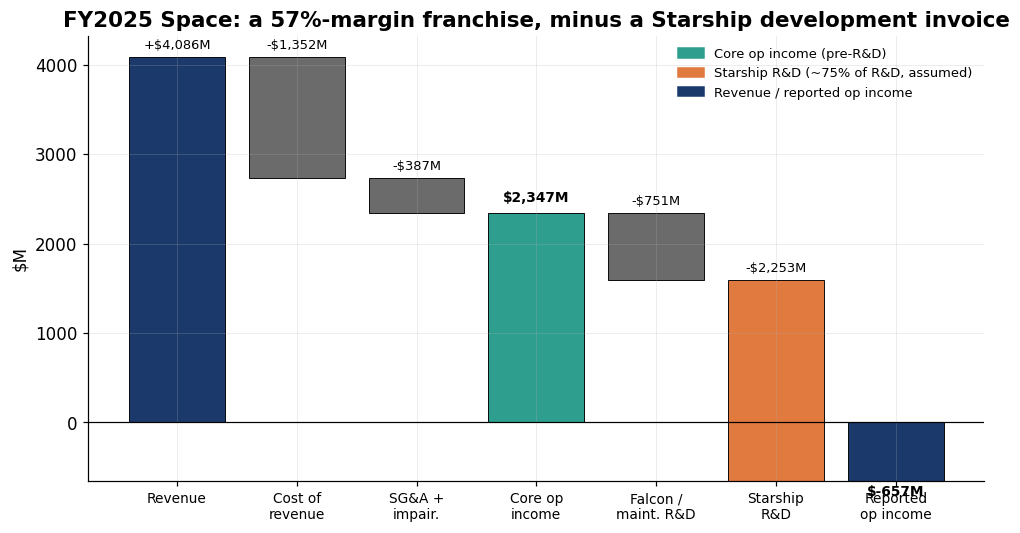

Core op income (pre-R&D): $2,347M (57% margin)  ->  after $3,004M R&D: $-657M


In [7]:
# Waterfall: from Space revenue down to the reported loss, isolating the Starship R&D "invoice".
p = "FY2025"
rev   = R.revenue[p]; cogs = R.cogs[p]; sga = R.sga[p]; imp = R.impairment[p]; rnd = R.rnd[p]
core  = rev - cogs - sga - imp                                  # pre-R&D operating income
ss_rnd = STARSHIP_RND_SHARE * rnd                               # Starship share (assumption)
base_rnd = rnd - ss_rnd                                         # Falcon / maintenance R&D
reported = core - rnd                                           # == R.op_income[p]

steps  = ["Revenue", "Cost of\nrevenue", "SG&A +\nimpair.", "Core op\nincome", "Falcon /\nmaint. R&D",
          "Starship\nR&D", "Reported\nop income"]
deltas = [rev, -cogs, -(sga + imp), None, -base_rnd, -ss_rnd, None]
colors = [NAVY, GREY, GREY, TEAL, GREY, ORANGE, NAVY]

fig, ax = plt.subplots(figsize=(9.2, 5))
running = 0.0
for i, (lbl, d, c) in enumerate(zip(steps, deltas, colors)):
    if d is None:                                              # totals drawn from zero
        total = core if lbl.startswith("Core") else reported
        ax.bar(i, total, color=c, edgecolor="black", lw=0.6)
        ax.text(i, total + (120 if total >= 0 else -160), f"${total:,.0f}M",
                ha="center", fontweight="bold", fontsize=9)
        running = total
    else:
        bottom = running if d >= 0 else running + d
        ax.bar(i, abs(d), bottom=bottom, color=c, edgecolor="black", lw=0.6)
        ax.text(i, bottom + abs(d) + 90, f"{'+' if d>=0 else '-'}${abs(d):,.0f}M",
                ha="center", fontsize=8.5)
        running += d
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(steps))); ax.set_xticklabels(steps, fontsize=9)
ax.set_ylabel("$M")
ax.set_title("FY2025 Space: a 57%-margin franchise, minus a Starship development invoice")
ax.legend(handles=[Patch(color=TEAL, label="Core op income (pre-R&D)"),
                   Patch(color=ORANGE, label=f"Starship R&D (~{STARSHIP_RND_SHARE:.0%} of R&D, assumed)"),
                   Patch(color=NAVY, label="Revenue / reported op income")],
          loc="upper right", fontsize=8.5)
charts.finish(fig); charts.save(fig, "space_starship_invoice", layout=False); plt.show()
print(f"Core op income (pre-R&D): ${core:,.0f}M ({core/rev:.0%} margin)  ->  after ${rnd:,.0f}M R&D: ${reported:,.0f}M")

In [8]:
# What does the launch franchise really earn? Steady-state Space op income vs the Starship R&D share.
# Idea: Falcon/maintenance R&D = (1 - share) * reported R&D is what remains once Starship normalizes;
# the rest is forward investment that, at commercialization, leaves the P&L (capitalizes).
shares = np.array([0.55, 0.65, 0.75, 0.85, 0.90])
sens = pd.DataFrame({"Starship R&D share": shares})
sens["Starship R&D ($M)"]          = shares * rnd
sens["Falcon / maint. R&D ($M)"]   = (1 - shares) * rnd
sens["Franchise op income ($M)"]   = core - (1 - shares) * rnd          # what Space earns ex-Starship
sens["Franchise op margin"]        = sens["Franchise op income ($M)"] / rev
display(fmt(sens.set_index("Starship R&D share"), pct=["Franchise op margin"]))

lo, hi = STARSHIP_RND_SHARE_BAND
fr_lo = core - (1 - hi) * rnd
fr_hi = core - (1 - lo) * rnd
print(f"Across the {lo:.0%}-{hi:.0%} Starship-share band, today's launch franchise earns "
      f"~${min(fr_lo,fr_hi):,.0f}-{max(fr_lo,fr_hi):,.0f}M of operating income —")
print("i.e. the Space segment's reported loss is entirely a function of how much Starship it is funding.")

,Starship R&D ($M),Falcon / maint. R&D ($M),Franchise op income ($M),Franchise op margin
Starship R&D share,,,,
0.550000,"1,652","1,352",995,24.4%
0.650000,"1,953","1,051","1,296",31.7%
0.750000,"2,253",751,"1,596",39.1%
0.850000,"2,553",451,"1,896",46.4%
0.900000,"2,704",300,"2,047",50.1%


Across the 55%-90% Starship-share band, today's launch franchise earns ~$995-2,047M of operating income —
i.e. the Space segment's reported loss is entirely a function of how much Starship it is funding.


**Strip Starship and the launch franchise earns roughly \$1.5–1.9B of operating income** (the
\$2,347M core, less whatever Falcon-sustaining R&D you assume). The reported \$(657)M loss is not a
broken business — it's a profitable monopoly voluntarily funding the most expensive R&D program in
the company. That reframes the valuation question entirely: the Space segment is **option value
(Starship) sitting on top of a cash-generative franchise**, not a loss-maker to be discounted. The
rest of the notebook prices the option.

## 5. Starship: the cost-per-kg lever — and the accounting hinge

Why pour \$3B/yr into Starship when Falcon already dominates? Because of the cost curve the S-1 quotes
from NASA. Reusability already took launch from a historical **\$18,500/kg** to **\$2,700/kg** (Falcon 9,
2010) to **\$1,400/kg** (Falcon Heavy, 2018). SpaceX's stated aim for Starship is a **≥99% reduction
vs the \$18,500 historical average — roughly \$185/kg or less.** Payload per launch scales the same
way: Falcon 9 ~23t to LEO, Falcon Heavy ~64t, **Starship V3 designed for 100t fully reusable**, with
future generations targeting ~200t.

**What that unlocks** (three things, in rough order of near-term value):
1. **Collapse internal deployment cost.** Every Starlink satellite — and, the S-1 says, future
   *AI-compute* satellites — rides to orbit on SpaceX's own rockets. Cutting \$/kg by ~85–90% vs
   Falcon directly compounds the Connectivity (and AI) economics.
2. **Make orbital AI compute physically possible.** The S-1's vision — *~1 million metric tons to
   orbit per year to power ~100 GW of AI compute* — is a rounding error at \$185/kg and a fantasy at
   \$1,400/kg. Starship is the precondition, not a nice-to-have.
3. **New external markets** — bulk constellations, heavy national-security payloads, lunar/Mars
   (NASA), point-to-point — that don't close at Falcon prices.

**The accounting hinge** (this is what makes Starship show up in the numbers): today Starship is
*expensed* as R&D. The S-1 states that *"at commercialization, Starship costs generally will be
capitalized and then depreciated in cost of revenue of the segment associated with the payload
delivered."* So commercialization does two things at once — the **\~\$2–3B R&D drag leaves the Space
P&L**, and the cost re-emerges as depreciation *in whichever segment flies the payload* (mostly
Connectivity/AI, for internal missions). Space's reported profitability swings up almost
mechanically.

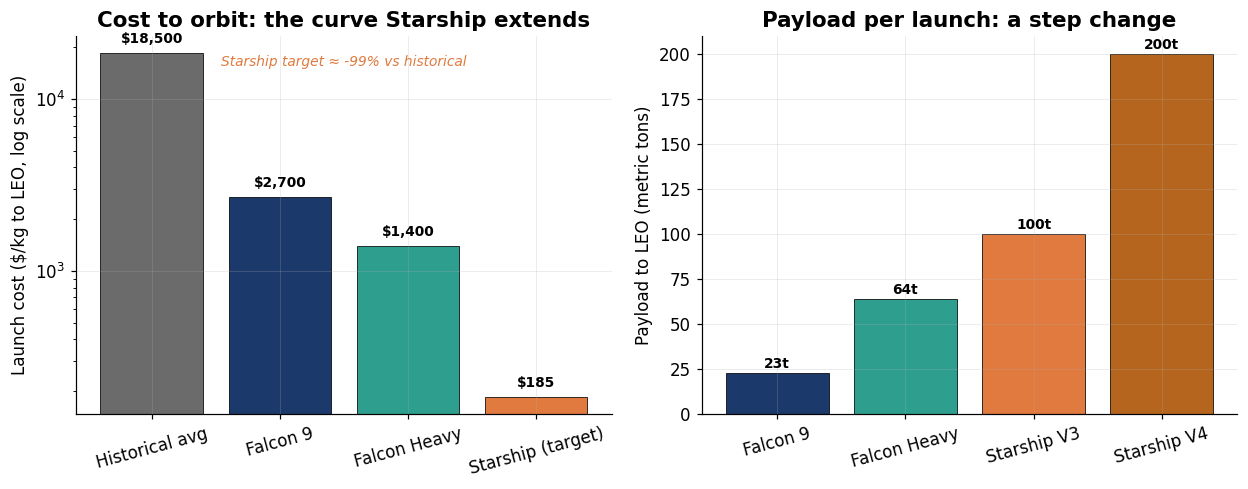

In [9]:
# The S-1's own cost-per-kg curve (log axis) + payload capacity by vehicle.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.6))

labels = list(COST_PER_KG.keys()); vals = list(COST_PER_KG.values())
cc = [GREY, NAVY, TEAL, ORANGE]
axL.bar(labels, vals, color=cc, edgecolor="black", lw=0.5)
axL.set_yscale("log")
axL.set_ylabel("Launch cost ($/kg to LEO, log scale)")
axL.set_title("Cost to orbit: the curve Starship extends")
for i, v in enumerate(vals):
    axL.text(i, v * 1.15, f"${v:,.0f}", ha="center", fontsize=9, fontweight="bold")
axL.tick_params(axis="x", labelrotation=15)
red = 1 - COST_PER_KG["Starship (target)"] / COST_PER_KG["Historical avg"]
axL.text(0.5, 0.92, f"Starship target ≈ -{red:.0%} vs historical", transform=axL.transAxes,
         ha="center", fontsize=9, style="italic", color=ORANGE)

pl_labels = list(PAYLOAD_T_LEO.keys()); pl_vals = list(PAYLOAD_T_LEO.values())
cc2 = [NAVY, TEAL, ORANGE, "#b5651d"]
axR.bar(pl_labels, pl_vals, color=cc2, edgecolor="black", lw=0.5)
axR.set_ylabel("Payload to LEO (metric tons)")
axR.set_title("Payload per launch: a step change")
for i, v in enumerate(pl_vals):
    axR.text(i, v + 3, f"{v}t", ha="center", fontsize=9, fontweight="bold")
axR.tick_params(axis="x", labelrotation=15)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "space_cost_curve", layout=False); plt.show()

In [10]:
# Why Starship is mandatory for orbital AI: cost to lift the S-1's ~1,000,000 t/yr target.
TARGET_T_YR = 1_000_000        # S-1: ~1M metric tons/yr to orbit to power ~100 GW of AI compute
kg = TARGET_T_YR * 1_000
ai = pd.Series({
    "At Falcon Heavy ($1,400/kg)": kg * COST_PER_KG["Falcon Heavy"] / 1e9,
    "At Starship target ($185/kg)": kg * COST_PER_KG["Starship (target)"] / 1e9,
}, name="$B/yr to lift 1,000,000 t")
display(ai.round(0).to_frame())
print(f"Lifting the S-1's orbital-AI mass target costs ~${ai.iloc[0]:,.0f}B/yr on Falcon Heavy vs "
      f"~${ai.iloc[1]:,.0f}B/yr on Starship —")
print(f"a {1 - ai.iloc[1]/ai.iloc[0]:.0%} reduction. Orbital AI compute is an economic non-starter without Starship.")

,"$B/yr to lift 1,000,000 t"
"At Falcon Heavy ($1,400/kg)",1400.0
At Starship target ($185/kg),185.0


Lifting the S-1's orbital-AI mass target costs ~$1,400B/yr on Falcon Heavy vs ~$185B/yr on Starship —
a 87% reduction. Orbital AI compute is an economic non-starter without Starship.


### 5.1 But customer demand is flat — so why does more capacity matter?

The honest objection to everything above: SpaceX's *customer* launch count is flat-to-falling (43 in
FY2025, a ~25-launch run-rate in Q1-2026), and the S-1 openly says it **backfills otherwise-idle
launch slots with Starlink**. If SpaceX already has more launch capacity than paying customers want,
how does a rocket that lifts *even more* mass add a single dollar of revenue? A bigger firehose is
useless if the bucket is already full.

It's the right question, and it kills the lazy bull case ("Starship = 10× the launches = 10× Space
revenue"). That story is wrong: the customer launch market is **demand-constrained**, and Starship
does nothing for demand SpaceX can't already serve with Falcon. What Starship actually changes is
*which businesses are physically and economically possible* once \$/kg falls ~85–90% — and those
businesses are mostly **SpaceX's own**:

- **Orbital AI compute → the AI segment.** The S-1's vision (~1M tons/yr to orbit for ~100 GW of
  compute) is **mass-constrained, not demand-constrained**: the appetite for AI compute is effectively
  unlimited; the blocker is the cost of lifting power+silicon to orbit. At Falcon Heavy's \$1,400/kg
  it's a ~\$1.4T/yr fantasy; at Starship's target it might pencil. Starship is the *precondition* — but
  the revenue books in **AI**, not Space.
- **Next-gen Starlink → the Connectivity segment (the flywheel).** Bigger, heavier V2/V3 satellites
  (more capacity and direct-to-cell per bird) only make sense with cheap, high-cadence launch. The
  Connectivity notebook's **§7.7 affordability–cost flywheel** makes this explicit: as internal launch
  cost glides toward **~\$8M/launch** (vs **\$17.5M** on Falcon today), ARPU can fall faster, the
  reachable subscriber ceiling **expands**, and margin is *computed* from cheaper deployment — not held
  flat. That is **elastic internal demand** (more subs at lower price because launch got cheaper). It
  never appears as Space revenue; it books in **Connectivity** FCF.
- **Genuinely new external demand → the Space segment.** A slice of demand *is* price-elastic and
  simply doesn't close at Falcon prices: third-party mega-constellations, heavy national-security
  payloads, lunar/Mars and NASA Artemis (HLS). This is real *new* Space revenue — and it's the
  **smallest** of the three.

So the defensible read: **Starship is an infrastructure bet whose payoff is collected mostly in AI and
Connectivity, plus a modest new external launch market in Space.** For the Space segment in isolation,
the dominant effect isn't a wall of new revenue — it's the **mechanical reversal of the ~\$2.5B R&D
drag** when Starship capitalizes (§4 hinge). The §6 model is built to respect this: external Starship
revenue stays deliberately modest, and we refuse to book the internal payoff here (that would
double-count what belongs to the other two segments).

### 5.2 How much of the Starship story do we actually believe?

SpaceX is the one company whose audacious cost claims have earned *partial* credit — it has done the
implausible twice (Falcon 9, then Falcon Heavy reuse). But *"designed to"* and *"we aim to"* are not
*"we did,"* and the genuinely hard part — a rapidly reusable upper stage at high cadence — is exactly
what has historically slipped. So we grade the S-1's claims and treat each accordingly:

| S-1 claim | Status | How we treat it |
|---|---|---|
| Falcon 9 / Heavy reuse → ~\$2,700 / \$1,400 per kg; >80% of world mass to orbit | **Demonstrated** | Take as fact — audited operating history. |
| Booster catch & reuse on Starship | **Demonstrated (early)** | Capability is real; reliability and rapid refly are not yet proven. |
| Starship V3 delivers ~100t reusable (200t future) | **Design target** | Plausible, not shown. Treat as a *ceiling* the cadence ramps toward. |
| ≥99% cost cut → ~\$185/kg | **Aspirational** | Directional, not a base case. We assume a large *but smaller* cut. |
| ~1M tons/yr → 100 GW orbital compute | **Vision / TAM marketing** | A flourish, not a forecast. ~Zero credit in Space; only cautious credit in AI. |
| *When* Starship serves commercial payloads | **Not disclosed** | Our scenario lever — the catalyst that separates bear / base / bull (§6). |

**Our stance:** demonstrated economics = fact; design targets = ramps, not step-functions;
visionary tonnage = upside we do not underwrite. That keeps the jokes as garnish and the model honest.

The cost curve is the whole thesis in one picture: Starship isn't a bigger Falcon, it's the asset that
makes SpaceX's two *other* segments (mass-hungry Starlink, absurdly mass-hungry orbital AI) economically
possible — which is why its value mostly shows up *there*, not in Space (§5.1). For the Space segment,
the capitalize-at-commercialization rule means the day Starship starts flying paying payloads is the
day the reported P&L stops bleeding. So the question that actually moves the Space valuation isn't
*how much* — it's **when**. That timing is the catalyst we vary next.

## 6. Modeling Starship revenue — the catalyst is *timing*

The one fact the S-1 won't give us is **when** Starship serves paying payloads — and per §4–§5 that
date is what actually swings the Space valuation, because it's when the ~\$2.5B R&D drag flips to
capitalized cost. So we define the scenarios by a **commercialization year** and attach **concrete,
falsifiable milestones** to each. Everything else (cadence ramp, external pricing, growth) is a
*consequence* of how fast and how well the program matures — not an independent dial.

| Catalyst | 🐻 **Bear — 2029** | **Base — 2028** | 🐂 **Bull — 2027** |
|---|---|---|---|
| Full-stack reuse (booster **+ ship**, rapid refly) | slips; ship reuse stays hard, anomalies recur | demonstrated by 2027, refurb slower than hoped | reliable & rapid by 2026 |
| Payload to LEO at commercialization | well under design (~50–70t) | ramping toward 100t | ~100t, V3 on spec |
| Regulatory / pads (FAA cadence, 2nd pad at Cape) | environmental & cadence delays | Starbase scaled, Cape coming online | multi-pad high-cadence approved |
| First commercial payloads | 2029 | 2028 | 2027; NASA HLS milestones hit |
| External \$/kg vs Falcon | only modestly better | clearly better, not yet "the dream" | approaching the low hundreds |
| **Net effect on Space** | Starship ≈ internal tool; thin external market | real new external lift + internal scale | earlier commercial payloads; still modest *external* revenue (flywheel is internal) |

These map to model levers (all assumptions, flagged): the **commercialization year**, an **external-
mission ramp** and **price per mission**, and how fast **R&D normalizes**. Keep the §5.1 caveat in
view — external Starship revenue is deliberately kept modest (demand-constrained), so the scenario
spread is driven mostly by *timing of the R&D reversal* plus a small, genuinely-new external market.
The big internal payoff is credited in the AI and Connectivity notebooks, not here.

In [11]:
# ---- Forward Space-segment scenarios (canonical: analysis.space_economics) ----
from analysis.space_economics import project_space_forward, SPACE_SCENARIOS, SS_YEAR

FWD = ["FY2026E", "FY2027E", "FY2028E", "FY2029E", "FY2030E"]
YRS = [2026, 2027, 2028, 2029, 2030]

# Chart-only overlays (not in the module — colors + narrative catalysts).
scen = {
    name: {**SPACE_SCENARIOS[name],
           "color": c,
           "catalyst": cat}
    for name, c, cat in [
        ("Bear", GREY, "ship reuse slips; FAA / environmental delays"),
        ("Base", NAVY, "full reuse by 2027; refurb ramps gradually"),
        ("Bull", TEAL, "reliable rapid reuse by 2026; V3 on spec"),
    ]
}

def _to_period_labels(df):
    out = df.copy()
    out.index = [f"FY{y}E" for y in out.index]
    out.index.name = "period"
    return out

proj = {name: _to_period_labels(project_space_forward(name)) for name in scen}

summary = pd.DataFrame({
    "Commercial year":         [str(scen[s]["commercial_year"]) for s in scen],
    "Catalyst":                [scen[s]["catalyst"] for s in scen],
    "FY2030E revenue ($M)":    [proj[s].loc["FY2030E", "revenue"] for s in scen],
    "FY2030E ext. Starship ($M)": [proj[s].loc["FY2030E", "ss_rev"] for s in scen],
    "FY2030E op income ($M)":  [proj[s].loc["FY2030E", "op_income"] for s in scen],
}, index=list(scen))
print("SCENARIO SUMMARY (catalyst = commercialization timing):")
display(fmt(summary))

print("\nBASE CASE detail (commercialization 2028):")
display(fmt(proj["Base"][["cust_rev", "ld_rev", "ss_launches", "ss_rev", "revenue", "rnd", "op_income", "op_margin"]],
            pct=["op_margin"], one=["ss_launches"]))

oi = pd.DataFrame({name: proj[name]["op_income"] for name in scen}, index=FWD)
oi.loc["FY2025 (actual)"] = R.op_income["FY2025"]
oi = oi.reindex(["FY2025 (actual)"] + FWD)
print("\nSpace segment operating income by scenario ($M):")
display(fmt(oi))


SCENARIO SUMMARY (catalyst = commercialization timing):


,Commercial year,Catalyst,FY2030E revenue ($M),FY2030E ext. Starship ($M),FY2030E op income ($M)
Bear,2029,ship reuse slips; FAA / environmental delays,"4,845",210,433
Base,2028,full reuse by 2027; refurb ramps gradually,"6,195",990,"2,596"
Bull,2027,reliable rapid reuse by 2026; V3 on spec,"7,700","1,980","3,603"



BASE CASE detail (commercialization 2028):


,cust_rev,ld_rev,ss_launches,ss_rev,revenue,rnd,op_income,op_margin
period,,,,,,,,
FY2026E,"2,653","1,631",0.0,0,"4,284","3,720","-1,202",-28.1%
FY2027E,"2,733","1,761",0.0,0,"4,494","3,720","-1,062",-23.6%
FY2028E,"2,815","1,902",3.0,270,"4,987","3,720",-732,-14.7%
FY2029E,"2,899","2,054",6.0,540,"5,494","2,460",867,15.8%
FY2030E,"2,986","2,219",11.0,990,"6,195","1,200","2,596",41.9%



Space segment operating income by scenario ($M):


,Bear,Base,Bull
FY2025 (actual),-657,-657,-657
FY2026E,"-1,267","-1,202","-1,148"
FY2027E,"-1,197","-1,062",-725
FY2028E,"-1,124",-732,973
FY2029E,-977,867,"2,835"
FY2030E,433,"2,596","3,603"


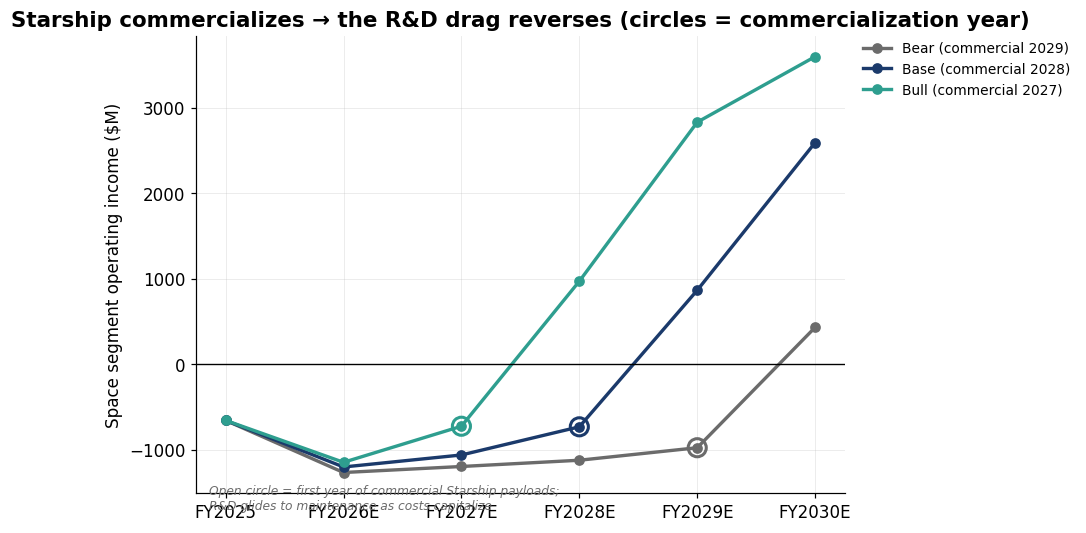

In [12]:
# The op-income flip: the Starship R&D drag reverses as the program commercializes.
fig, ax = plt.subplots(figsize=(9.2, 5))
xall = ["FY2025"] + FWD
for name, cfg in scen.items():
    y = [R.op_income["FY2025"]] + list(proj[name]["op_income"].values)
    ax.plot(xall, y, marker="o", lw=2.2, color=cfg["color"], label=f"{name} (commercial {cfg['commercial_year']})")
    cy = cfg["commercial_year"]
    if cy in YRS:
        xi = FWD[YRS.index(cy)]
        yi = proj[name]["op_income"].loc[xi]
        ax.scatter([xi], [yi], s=140, facecolors="none", edgecolors=cfg["color"], lw=2, zorder=5)
ax.axhline(0, color="black", lw=0.9)
ax.set_ylabel("Space segment operating income ($M)")
ax.set_title("Starship commercializes → the R&D drag reverses (circles = commercialization year)")
charts.legend_outside(ax, loc="upper left", fontsize=9)
ax.text(0.02, 0.02, "Open circle = first year of commercial Starship payloads;\nR&D glides to maintenance as costs capitalize",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, style="italic", color=GREY)
charts.finish(fig); charts.save(fig, "space_starship_scenarios", layout=False); plt.show()

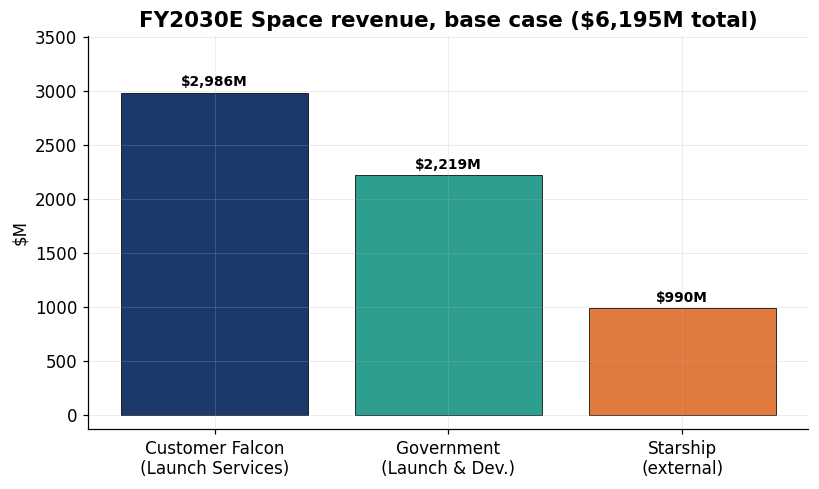

Base-case FY2030E Space revenue $6,195M, of which external Starship $990M (16%).
Even in the model, external Starship revenue is the SMALLER prize — the big one (cheap internal
deployment of Starlink + AI compute) shows up in the Connectivity and AI segments, not here.


In [13]:
# Where the FY2030 revenue comes from (base case): customer Falcon, government, Starship external.
b30 = proj["Base"].loc["FY2030E"]
build = pd.Series({
    "Customer Falcon\n(Launch Services)": b30["cust_rev"],
    "Government\n(Launch & Dev.)":        b30["ld_rev"],
    "Starship\n(external)":               b30["ss_rev"],
}, name="FY2030E Space revenue ($M)")

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.bar(build.index, build.values, color=[NAVY, TEAL, ORANGE], edgecolor="black", lw=0.5)
for i, v in enumerate(build.values):
    ax.text(i, v + 60, f"${v:,.0f}M", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("$M")
ax.set_title(f"FY2030E Space revenue, base case (${build.sum():,.0f}M total)")
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "space_fy2030_revenue_build", layout=False); plt.show()
print(f"Base-case FY2030E Space revenue ${build.sum():,.0f}M, of which external Starship "
      f"${b30['ss_rev']:,.0f}M ({b30['ss_rev']/build.sum():.0%}).")
print("Even in the model, external Starship revenue is the SMALLER prize — the big one (cheap internal")
print("deployment of Starlink + AI compute) shows up in the Connectivity and AI segments, not here.")

**What this sets up (§7 closes to cash).** Four takeaways the Space-segment forecast should carry forward:

1. **The franchise floor.** Even crediting Starship *nothing*, the customer-launch + government book is
   a structurally profitable business once you stop expensing Starship against it (§4) — the downside
   support for the segment regardless of how the rocket goes.
2. **Timing is the catalyst, not magnitude.** The bear/base/bull spread is driven mostly by *when* the
   ~\$2.5B R&D drag reverses (§4 hinge), which is why we keyed the scenarios to commercialization year:
   a 2027 vs 2029 start is the difference between the segment turning the corner mid-decade (~\$4B op
   income by FY2030) or barely breaking even (~\$0.4B).
3. **External Starship revenue stays a slice — on purpose.** Customer Falcon demand is flat
   (§5.1); the §7.7 flywheel's demand surge is *internal* and books in Connectivity. We hold *external*
   Starship revenue modest even in bull (~\$0.2–2B by FY2030 vs ~\$3–6B from the legacy franchise).
   Starship's dominant value — the ~85–90% collapse in internal deployment cost — is credited in the
   **AI and Connectivity** segments, not double-counted here.
4. **Discount the vision, keep the mechanics.** Per the credibility ledger (§5.2), we underwrite the
   demonstrated economics and the (mechanical) R&D reversal, and we do *not* underwrite the \$185/kg
   dream or the 1M-tons/yr orbital-compute TAM. If those land, they're upside — mostly to other segments.

The one-line summary holds, sharpened: **Space is a profitable launch monopoly wearing a Starship-
shaped loss, and the only question that moves its valuation is when that loss converts into an asset.**

## 7. Forward free cash flow — Starship commercialization in cash terms

§6 showed operating income flipping positive when Starship **commercializes** (R&D expensed today
capitalizes tomorrow) and a **modest** external launch book ramps on top of the Falcon franchise.
This section closes the same paths to **free cash flow** — the number a DCF discounts.

$$\text{FCF} = \text{operating income} + \text{D\&A} + \text{SBC} - \text{capex}$$

Same definition as Connectivity §3/§8 and ``analysis/dcf.py``. FY2025 is anchored to reported
Space fundamentals; FY2026–FY2030 use the canonical engine in ``analysis.space_economics``
(also what ``dcf.py`` calls for the Space segment).

**What Starship does *here* (Space segment only).**
1. **R&D spend falls** after commercialization — the ~\$3.7B run-rate glides to ~\$1.2B maintenance;
   that is the dominant cash swing in operating income.
2. **A thin external revenue ramp** — ``SS_RAMP`` missions × scenario price; price-elastic demand
   that does not close on Falcon (§5.1).
3. **Capex still rises** through FY2030 (Starship tooling + fleet); D&A rises too once development
   capitalizes. So Space FCF can stay **negative** even as op income recovers — the segment is
   mid-build, not a cash cow yet.

**What Starship does *there* (Connectivity — the big prize).** Cheaper internal launches
(§7.7 flywheel in the Connectivity notebook) cut Starlink deployment capex and expand the
subscriber ceiling. That is **not** booked as Space revenue; do not double-count it here.


In [14]:
# FY2025 FCF anchor (reported fundamentals) + forward paths from the canonical engine.
SBC_PCT = R.sbc["FY2025"] / R.revenue["FY2025"]
FCF25 = (R.op_income + R.da + R.sbc + R.impairment - R.capex)["FY2025"]

fcf = {name: _to_period_labels(project_space_forward(name)) for name in scen}

ff25 = pd.Series({
    "Operating income": R.op_income["FY2025"],
    "+ D&A":            R.da["FY2025"],
    "+ SBC":            R.sbc["FY2025"],
    "- Capex":          -R.capex["FY2025"],
    "= FCF":            FCF25,
}, name="FY2025 ($M)")
display(fmt(ff25.to_frame().T))

print(f"FY2025 Space FCF: ${FCF25:,.0f}M — negative because ${R.capex['FY2025']:,.0f}M capex overwhelms "
      f"the segment even before the full Starship R&D run-rate.")


,Operating income,+ D&A,+ SBC,- Capex,= FCF
FY2025 ($M),-657,757,515,"-3,832","-3,179"


FY2025 Space FCF: $-3,179M — negative because $3,832M capex overwhelms the segment even before the full Starship R&D run-rate.


In [15]:
# Forward FCF bridge — base case shown; all three scenarios in the chart below.
def fcf_bridge(df):
    t = pd.DataFrame(index=df.index)
    t["Revenue"]     = df["revenue"]
    t["Op income"]   = df["op_income"]
    t["R&D"]         = df["rnd"]
    t["+ D&A"]       = df["da"]
    t["+ SBC"]       = df["sbc"]
    t["- Capex"]     = -df["capex"]
    t["= FCF"]       = df["fcf"]
    t["FCF margin"]  = df["fcf_margin"]
    return t

display(fmt(fcf_bridge(fcf["Base"]), pct=["FCF margin"]))

# Starship commercialization: R&D and external revenue vs base timing (FY2030).
b30, be30 = fcf["Base"].loc["FY2030E"], fcf["Bear"].loc["FY2030E"]
starship_cash = pd.Series({
    "Base FY2030 R&D ($M)":              b30["rnd"],
    "Bear FY2030 R&D ($M)":              be30["rnd"],
    "R&D saved vs Bear (Base)":          be30["rnd"] - b30["rnd"],
    "Base FY2030 ext. Starship rev":     proj["Base"].loc["FY2030E", "ss_rev"],
    "Base FY2030 FCF":                   b30["fcf"],
    "Bear FY2030 FCF":                   be30["fcf"],
}, name="Starship timing → cash (Base vs Bear)")
display(fmt(starship_cash.to_frame().T))


,Revenue,Op income,R&D,+ D&A,+ SBC,- Capex,= FCF,FCF margin
period,,,,,,,,
FY2026E,"4,284","-1,202","3,720",848,540,"-4,254","-4,068",-95.0%
FY2027E,"4,494","-1,062","3,720",950,566,"-4,721","-4,267",-95.0%
FY2028E,"4,987",-732,"3,720","1,064",629,"-5,241","-4,281",-85.8%
FY2029E,"5,494",867,"2,460","2,447",692,"-5,817","-1,811",-33.0%
FY2030E,"6,195","2,596","1,200","2,590",781,"-6,457",-491,-7.9%


,Base FY2030 R&D ($M),Bear FY2030 R&D ($M),R&D saved vs Bear (Base),Base FY2030 ext. Starship rev,Base FY2030 FCF,Bear FY2030 FCF
Starship timing → cash (Base vs Bear),"1,200","2,460","1,260",990,-491,"-1,998"


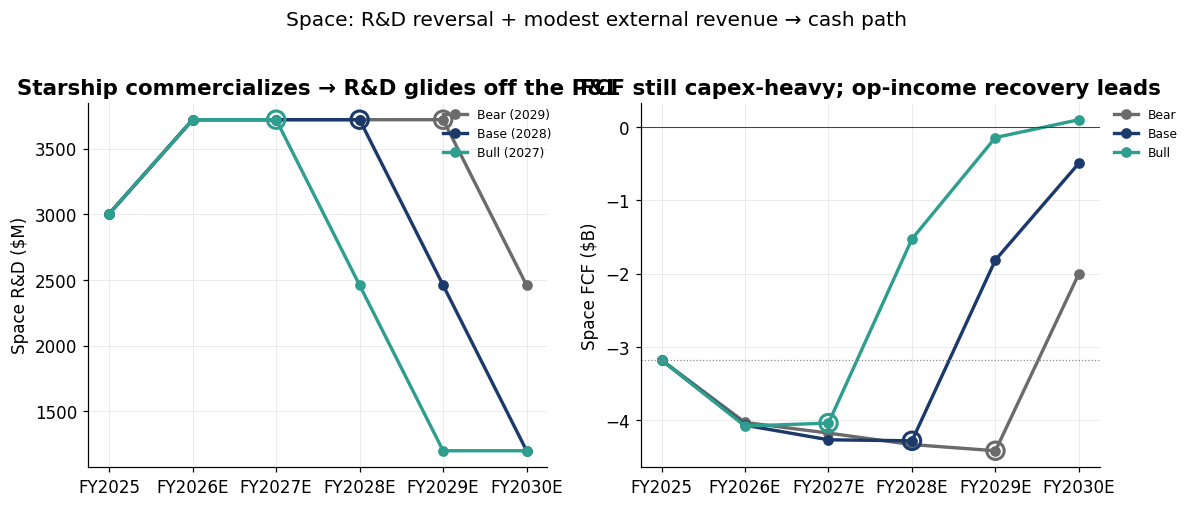

In [16]:
# R&D and FCF paths: commercialization year is the hinge (open circle = first commercial payloads).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
xall = ["FY2025"] + FWD
for name, cfg in scen.items():
    rnd_y = [R.rnd["FY2025"]] + list(fcf[name]["rnd"].values)
    fcf_y = [FCF25 / 1000] + list(fcf[name]["fcf"].values / 1000)
    ax1.plot(xall, rnd_y, "o-", lw=2.2, color=cfg["color"], label=f"{name} ({cfg['commercial_year']})")
    ax2.plot(xall, fcf_y, "o-", lw=2.2, color=cfg["color"], label=f"{name}")
    cy = cfg["commercial_year"]
    if cy in YRS:
        xi = FWD[YRS.index(cy)]
        ax1.scatter([xi], [fcf[name].loc[xi, "rnd"]], s=130, facecolors="none",
                    edgecolors=cfg["color"], lw=2, zorder=5)
        ax2.scatter([xi], [fcf[name].loc[xi, "fcf"] / 1000], s=130, facecolors="none",
                    edgecolors=cfg["color"], lw=2, zorder=5)
ax1.set_ylabel("Space R&D ($M)")
ax1.set_title("Starship commercializes → R&D glides off the P&L")
charts.legend_outside(ax1, fontsize=8, loc="upper right")
ax2.axhline(0, color="#444", lw=0.7)
ax2.axhline(FCF25 / 1000, color="#888", ls=":", lw=0.8)
ax2.set_ylabel("Space FCF ($B)")
ax2.set_title("FCF still capex-heavy; op-income recovery leads")
charts.legend_outside(ax2, fontsize=8)
fig.suptitle("Space: R&D reversal + modest external revenue → cash path", y=1.02)
charts.finish(fig); charts.save(fig, "space_forward_fcf", layout=False); plt.show()


,Δ Customer + gov revenue,Δ External Starship rev,Δ R&D,Δ Op income,Δ D&A,Δ SBC,Δ Capex,Δ FCF
Base: FY2025 → FY2030E ($M),"1,119",990,"-1,804","3,253","1,833",266,"2,625","2,688"


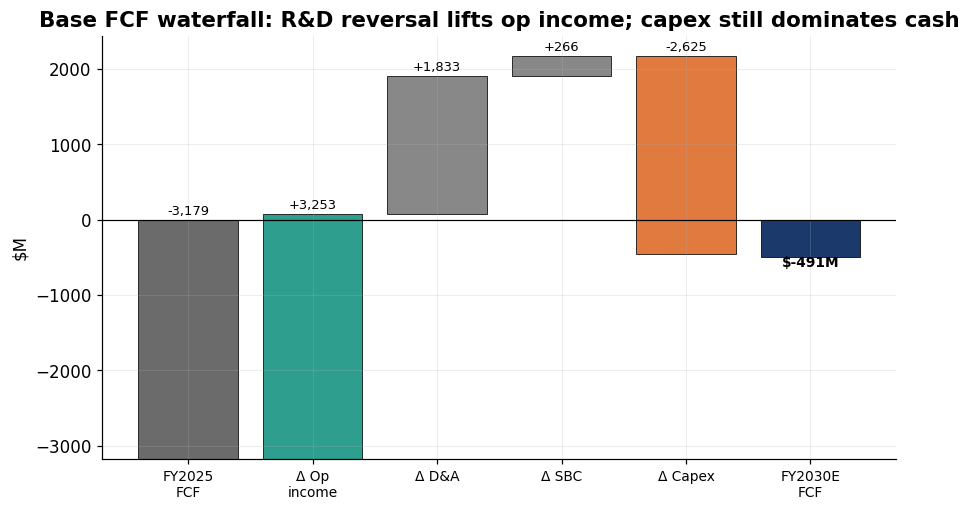

In [17]:
# FY2030 base case: what changed vs FY2025? (exact FCF bridge.)
p25, p30 = "FY2025", "FY2030E"
b = fcf["Base"]
d_op  = b.loc[p30, "op_income"] - R.op_income[p25]
d_da  = b.loc[p30, "da"] - R.da[p25]
d_sbc = b.loc[p30, "sbc"] - R.sbc[p25]
d_cx  = b.loc[p30, "capex"] - R.capex[p25]
d_fcf = b.loc[p30, "fcf"] - FCF25

decomp = pd.Series({
    "Δ Customer + gov revenue":  (proj["Base"].loc[p30, "cust_rev"] + proj["Base"].loc[p30, "ld_rev"])
                                 - (R.launch_services[p25] + R.launch_dev[p25]),
    "Δ External Starship rev":   proj["Base"].loc[p30, "ss_rev"],
    "Δ R&D":                     b.loc[p30, "rnd"] - R.rnd[p25],
    "Δ Op income":               d_op,
    "Δ D&A":                     d_da,
    "Δ SBC":                     d_sbc,
    "Δ Capex":                   d_cx,
    "Δ FCF":                     d_fcf,
}, name=f"Base: {p25} → {p30} ($M)")
display(fmt(decomp.to_frame().T))

fig, ax = plt.subplots(figsize=(8.4, 4.8))
steps  = ["FY2025\nFCF", "Δ Op\nincome", "Δ D&A", "Δ SBC", "Δ Capex", "FY2030E\nFCF"]
deltas = [FCF25, d_op, d_da, d_sbc, -d_cx, None]
colors = [GREY, TEAL, "#888", "#888", ORANGE, NAVY]
running = 0.0
for i, (lbl, d, c) in enumerate(zip(steps, deltas, colors)):
    if d is None:
        total = b.loc[p30, "fcf"]
        ax.bar(i, total, color=c, edgecolor="k", lw=0.5)
        ax.text(i, total + (90 if total >= 0 else -130), f"${total:,.0f}M", ha="center", fontweight="bold", fontsize=9)
    else:
        bottom = running if d >= 0 else running + d
        ax.bar(i, abs(d), bottom=bottom, color=c, edgecolor="k", lw=0.5)
        ax.text(i, bottom + abs(d) + 70, f"{d:+,.0f}", ha="center", fontsize=8.5)
        running += d
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(steps))); ax.set_xticklabels(steps, fontsize=9)
ax.set_ylabel("$M")
ax.set_title("Base FCF waterfall: R&D reversal lifts op income; capex still dominates cash")
charts.finish(fig); charts.save(fig, "space_fcf_decomposition", layout=False); plt.show()


In [18]:
# Square with analysis/dcf.py (must match — same project_space_forward engine).
from analysis import dcf

dcf_space = {s: dcf.project_segments(s, dcf._actuals())["Space"] for s in scen}
chk = pd.DataFrame({
    "Notebook FCF": [fcf[s].loc["FY2030E", "fcf"] for s in scen],
    "dcf.py FCF":   [dcf_space[s].loc[2030, "fcf"] for s in scen],
    "Δ ($M)":       [fcf[s].loc["FY2030E", "fcf"] - dcf_space[s].loc[2030, "fcf"] for s in scen],
}, index=list(scen))
display(fmt(chk, one=["Δ ($M)"]))
assert (chk["Δ ($M)"].abs() < 0.01).all(), "space.ipynb FCF must match dcf.py"

cum = pd.Series({s: fcf[s].loc[FWD[0]:, "fcf"].sum() / 1000 for s in scen}, name="Cum. FCF FY2026-30 ($B)")
print("Cumulative explicit-period Space FCF (still small vs Connectivity):")
display(fmt(cum.to_frame().T, one=["Cum. FCF FY2026-30 ($B)"]))


,Notebook FCF,dcf.py FCF,Δ ($M)
Bear,"-1,998","-1,998",0.0
Base,-491,-491,0.0
Bull,103,103,0.0


Cumulative explicit-period Space FCF (still small vs Connectivity):


,Bear,Base,Bull
Cum. FCF FY2026-30 ($B),-19,-15,-10


**Space FCF in one sentence.** Starship commercialization is a **P&L and R&D accounting
event first** and a **cash event second**: R&D falling ~\$2.5B/yr lifts operating income sharply, but
**capex still outruns the franchise** through FY2030, so segment FCF remains negative in bear/base and
only turns barely positive in bull (~\$0.1B in FY2030). The DCF values Space on the **terminal**
normalized path (capex → maintenance), not this mid-build explicit period — see ``dcf.ipynb``.

**For the group model.** The funding story is unchanged: Connectivity's Starship dividend (cheaper
satellite deployment) is orders of magnitude larger than Space's own FCF. This section exists so the
Space notebook and ``dcf.py`` share one auditable cash bridge — R&D down, a little more commercial
revenue, capex/D&A still in flight.

## Open threads
- **Starship R&D share** is the single biggest assumption (§4); the S-1 anchors only the \$1,169M
  FY2024→25 *increment* as Starship. A disclosed Falcon-vs-Starship R&D split would tighten the
  franchise-earnings band materially.
- **Commercialization timing** (§6) is judgment, not disclosure. Track Starship V3 flight-test
  cadence and the first capitalized (vs expensed) Starship costs in future filings as the real signal.
- **Customer A concentration** — ~21% of *total* company revenue (FY2025), spanning all three
  segments, almost certainly the U.S. government; worth isolating how much rides in Space's Launch &
  Development book.
- **Dragon / crew** economics are bundled inside Launch Services here; a dedicated split (crew vs
  cargo vs Falcon) would sharpen the unit economics in §3.
- **Internal-deployment value of Starship** is quantified in §5 as a cost-curve and in Connectivity
  **§7.7** as a coupled flywheel (launch cost → ceiling → subs → computed margin). The full payoff
  belongs there and in AI — not in Space revenue (§5.1, §6).